---
title: Observation of robust and coherent non-Abelian hadron dynamics on noisy quantum processors
description: Simulate SU(2) lattice gauge theory hadron dynamics using the LSH framework on IBM quantum hardware.
---

# Observation of robust and coherent non-Abelian hadron dynamics on noisy quantum processors

*Usage estimate: 30 minutes on a Heron processor (ibm_boston or equivalent) (NOTE: This is an estimate only. Your runtime may vary.)*

## Learning outcomes

After completing this tutorial, you will have learned the following:

- How non-Abelian lattice gauge theories (specifically SU(2)) can be reformulated using the Loop-String-Hadron (LSH) framework for efficient quantum simulation
- How to construct Trotterized time-evolution circuits for an approximate SU(2) gauge theory Hamiltonian and map them onto qubits
- How to run these circuits on IBM Quantum&reg; hardware using the Qiskit Estimator primitive with readout error mitigation

## Prerequisites

It is recommended that you familiarize yourself with these topics:

- [Basics of quantum circuits and gates](/learning/courses/basics-of-quantum-information)
- [Introduction to the Qiskit Estimator primitive](/docs/guides/get-started-with-estimator)
- [Hamiltonian simulation and Trotterization](/docs/tutorials/explore-hamiltonian-simulation)
- Basic familiarity with quantum field theory concepts (helpful but not required; the background section covers the essentials)

## Background

### Motivation

Quantum Chromodynamics (QCD), the SU(3) gauge theory of the strong force, binds quarks into hadrons and governs confinement and string breaking. Classical lattice QCD methods excel at static properties but cannot simulate real-time dynamics due to the sign problem. Quantum computers offer a route around this barrier by encoding gauge field degrees of freedom directly onto qubits.

This tutorial demonstrates such a simulation: use IBM quantum hardware to simulate real-time hadron propagation in a (1+1)-dimensional SU(2) lattice gauge theory &mdash; the simplest non-Abelian gauge theory and a stepping stone toward full QCD.

### The Kogut-Susskind Hamiltonian

The theory is formulated on a 1D spatial lattice with staggered fermions (matter) on sites and SU(2) gauge fields on links. After rescaling to dimensionless form, the Hamiltonian is:

$$W = H_E^{\text{(KS)}} + \mu H_M + x H_I^{\text{(KS)}}$$

where $H_E$ is the chromoelectric field energy, $H_M$ is the staggered mass term, $H_I$ is the matter-gauge interaction (hopping) term, $\mu = 2\frac{m}{g}\sqrt{x}$ encodes the fermion mass, and $x = \frac{1}{g^2 a^2}$ is the interaction strength. The continuum limit of the theory lies at $N \to \infty$ and $x \to \infty$.

### The Loop-String-Hadron (LSH) framework

A key challenge is that the gauge field Hilbert space on each link is infinite-dimensional. The **Loop-String-Hadron (LSH)** framework addresses this by reformulating the theory in terms of gauge-invariant variables &mdash; loops of flux, strings connecting separated charges, and hadrons (gauge-singlet fermion pairs at a site). In the LSH basis, Gauss's law is satisfied automatically by construction, so every basis state is physical. Each lattice site is characterized by three quantum numbers $(n_l, n_i, n_o)$ representing the loop number, incoming string, and outgoing string, where $n_i, n_o \in \{0,1\}$ are fermionic and $n_l \geq 0$ is bosonic. The local fermion number is defined from these as $n_f(r) = n_i(r) + n_o(r)$ for even sites and $n_f(r) = 2 - [n_i(r) + n_o(r)]$ for odd sites.

### From full Hamiltonian to the quantum circuit: three key approximations

The quantum circuit does **not** simulate the full SU(2) Hamiltonian exactly. Instead, it implements a controlled series of approximations that are valid in the **weak-coupling regime** ($x \gg 1$). Understanding what is and is not approximated is essential:

**Approximation 1 &mdash; Weak-coupling limit for $H_I$:** The full interaction Hamiltonian $H_I^{\text{(LSH)}}$ (Eq. 16 in [1]) contains prefactors that depend on the bosonic quantum number $n_l$ via terms like $1/\sqrt{n_l+1}$. In the weak-coupling regime ($x \gg 1$), the dynamics is dominated by the electric term $H_E$, which favors states with large $n_l$. For $n_l \gg 1$, the ratio $n_l/(n_l+1) \to 1$ and all these prefactors simplify to unity. The interaction Hamiltonian then reduces to a purely local nearest-neighbor hopping:

$$H_I^{\text{approx}} = -\sum_r \left[\sigma^-(r)\sigma^+(r+1) + \sigma^+(r)\sigma^-(r+1)\right]$$

which is independent of $n_l$ and acts only on the fermionic $(n_i, n_o)$ qubits.

**Approximation 2 &mdash; Global-average-flux for $H_E$:** The electric energy depends on $n_l$ at each link. In the weak-coupling vacuum, $n_l$ is large and approximately uniform. Replace the site-dependent $n_l$ values with a single global average $\bar{n}_l$, making $H_E$ a diagonal phase proportional to the fermion configuration at each site:

$$H_E^{\text{approx}} = N h_E^0 + \sum_{\{r'\}} \left(\frac{\bar{n}_l}{2} + \frac{3}{4}\right)$$

where $\{r'\}$ sums over sites in the fermionic configuration $(n_i=0, n_o=1)$, and $h_E^0$ is a global phase you can ignore.

**Approximation 3 &mdash; Trotterization:** The time-evolution operator for a step of duration $\delta_\tau$ is decomposed as:

$$e^{-i\delta_\tau W} \approx e^{-i\tilde{m} H_M} \, e^{-i\delta_\tau H_E^{\text{approx}}} \, e^{-ic H_I^{\text{approx}}}$$

where $c = \delta_\tau x$, $\tilde{m} = \delta_\tau \mu$, and $\theta = -\delta_\tau(\bar{n}_l/2 + 3/4)$. This first-order Trotter decomposition introduces an error that vanishes as $\delta_\tau \to 0$. We fix $\delta_\tau = 0.0015$ throughout.

**The result** of these three approximations is that only the two fermionic qubits per site $(n_i, n_o)$ are dynamical &mdash; the bosonic $n_l$ degree of freedom has been absorbed into effective parameters. This yields a compact circuit with $2N$ qubits for $N$ lattice sites, where each Trotter step has constant two-qubit gate depth (13 per step).

### What this tutorial simulates

The tutorial simulates **hadron propagation**: starting from the strong-coupling vacuum (a product state), place a meson at the center of the lattice and evolve in time. The differential measurement protocol &mdash; running the circuit with and without the central meson, then subtracting &mdash; isolates the coherent hadron signal from both hardware noise and boundary effects. The result is a light-cone pattern of fermion density oscillations characteristic of a confined meson breathing mode.

## Requirements
Before starting this tutorial, be sure you have the following installed:

- Qiskit SDK v2.0 or later, with [visualization](https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization) support (`pip install 'qiskit[visualization]'`)
- Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)
- Pauli Propagation package (`pip install pauli-prop`)
- NumPy (`pip install numpy`)
- Matplotlib (`pip install matplotlib`)

## Setup

We begin by importing the necessary libraries and defining the helper functions that build the quantum circuits for the LSH time evolution. There are three core circuit-building functions:

1. **`pair_hamiltonian_circuit`**: Implements the two-qubit unitary $U_I$ for the approximate interaction Hamiltonian between neighboring sites. The gate decomposition is: $\text{CNOT} \to H \to R_z(-c) \to \text{CNOT} \to R_z(c) \to \text{CNOT} \to H \to \text{CNOT}$.

2. **`electric_hamiltonian_circuit`**: Implements the two-qubit unitary $U_E$ for the approximate electric field energy at each site. The gate decomposition is: $X \to R_z(\theta/2) \to \text{CNOT} \to R_z(-\theta/2) \to \text{CNOT} \to R_z(\theta/2) \to X$.

3. **`construct_circuit`**: Assembles the full Trotterized circuit, layering interaction, electric, and mass terms with SWAP gates to manage qubit connectivity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from typing import Optional

import warnings
warnings.filterwarnings('ignore')

In [2]:
def pair_hamiltonian_circuit(c: float) -> QuantumCircuit:
    """Two-qubit unitary for the approximate interaction Hamiltonian H_I.
    
    Implements exp(-i * c * H_I^approx) for one pair of neighboring sites,
    where c = delta_tau * x.
    """
    qc_temp = QuantumCircuit(2)
    qc_temp.cx(1, 0)
    qc_temp.h(1)
    qc_temp.rz(-c, 1)
    qc_temp.cx(0, 1)
    qc_temp.rz(c, 1)
    qc_temp.cx(0, 1)
    qc_temp.h(1)
    qc_temp.cx(1, 0)
    return qc_temp


def electric_hamiltonian_circuit(theta: float) -> QuantumCircuit:
    """Two-qubit unitary for the approximate electric field Hamiltonian H_E.
    
    Implements exp(-i * theta * H_E^approx) for one lattice site,
    where theta = -delta_tau * (n_bar_l / 2 + 3/4).
    """
    qc_temp = QuantumCircuit(2)
    qc_temp.x(0)
    qc_temp.rz(theta / 2, 0)
    qc_temp.cx(0, 1)
    qc_temp.rz(-theta / 2, 1)
    qc_temp.cx(0, 1)
    qc_temp.rz(theta / 2, 1)
    qc_temp.x(0)
    return qc_temp


def construct_circuit(
    num_lattice_point: int,
    num_trotter_steps: int,
    c: float,
    theta: float,
    m: float,
    theory: Optional[int] = 2,
    barriers: Optional[bool] = False,
    measurement: Optional[bool] = False,
    add_init_state: Optional[bool] = True,
    inverse_mid: Optional[bool] = False,
) -> QuantumCircuit:
    """Construct the full Trotterized time-evolution circuit.
    
    Builds a circuit implementing n Trotter steps of the approximate SU(2)
    LSH Hamiltonian evolution. The qubit layout uses a zigzag ordering:
    n_i(0), n_i(1), n_o(0), n_o(1), n_i(2), n_i(3), n_o(2), n_o(3), ...
    which minimizes the number of SWAP layers needed.
    
    Args:
        num_lattice_point: Number of lattice sites (num_qubits = 2 * num_lattice_point).
        num_trotter_steps: Number of Trotter steps.
        c: Interaction parameter (delta_tau * x).
        theta: Electric field phase parameter.
        m: Mass parameter (m_tilde = delta_tau * mu).
        theory: 1 for single chain, 2 for SU(2). Default 2.
        barriers: Insert barriers between Trotter layers for visualization.
        measurement: Append measurements at the end.
        add_init_state: Prepare the half-filled (strong-coupling vacuum) initial state.
        inverse_mid: Swap the central sites (for differential measurement protocol).
    """
    num_qubits = theory * num_lattice_point
    qc = QuantumCircuit(num_qubits)

    if num_trotter_steps <= 0:
        return qc

    # --- Initial state preparation ---
    if add_init_state:
        i = 1
        while i < num_lattice_point:
            for j in range(theory):
                qc.x(i + j * num_lattice_point)
            i = i + 2
        if inverse_mid:
            mid_lattice_qubits = [num_qubits // 2 - 1, num_qubits // 2]
            qc.x(mid_lattice_qubits)
    else:
        i = 1
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + 4

    # --- Trotter steps ---
    for step in range(num_trotter_steps):
        if barriers:
            qc.barrier()

        # First SWAP layer (skipped at step 0 — absorbed into initial state mapping)
        if step > 0:
            i = 1
            while i < num_qubits - 1:
                qc.swap(i, i + 1)
                i = i + 4

        # First layer of pair interactions
        j = 0
        while j < num_qubits - 2:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)
            j = j + 2
        if num_lattice_point % 2 == 0:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)

        # Second SWAP layer
        i = 1
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + theory

        # Second layer of pair interactions
        j = 2
        while j < num_qubits - 3:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)
            j = j + 2
        if num_lattice_point % 2 != 0:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)

        # Third SWAP layer
        i = 3
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + 2 * theory

        # Electric field term
        if theta != 0:
            e_circ = electric_hamiltonian_circuit(theta)
            for j in range(num_lattice_point):
                qc.compose(e_circ, [2 * j, 2 * j + 1], inplace=True)

        # Mass term: Rz(-m_tilde) for even sites, Rz(m_tilde) for odd sites
        for q in range(num_qubits):
            if q % 2 == 0:
                qc.rz(-1 * m, q)
            else:
                qc.rz(m, q)

    if measurement:
        qc.measure_all()

    return qc

In [3]:
def get_probabilities(expval: float):
    """Convert a Z-expectation value to site occupation probability.
    
    Since <Z> = p(0) - p(1), the occupation probability is p(1) = (1 - <Z>) / 2.
    """
    p1 = round((1 - expval) / 2, 3)
    return p1


def get_number(expval_data, num_lattice_point):
    """Convert raw Z-expectation values to staggered fermion number n_f at each site.
    
    n_f(r) = n_i(r) + n_o(r)           for even r
    n_f(r) = 2 - [n_i(r) + n_o(r)]     for odd r
    
    The two qubits per site encode (n_i, n_o), and occupation probabilities
    give us <n_i> and <n_o>.
    """
    N = []
    for expvals in expval_data:
        Pstep = [get_probabilities(expval) for expval in expvals]
        Nstep = []
        for k in range(num_lattice_point):
            val = Pstep[2 * k] + Pstep[2 * k + 1]
            a = 2 * (k % 2) + (1 - 2 * (k % 2)) * val
            Nstep.append(float(a))
        N.append(Nstep)
    return N


def calculate_difference(N, N_mid, num_lattice_point):
    """Differential measurement protocol: |n_f(meson) - n_f(vacuum)|.
    
    Subtracting the vacuum (SCV) evolution from the meson evolution
    isolates the coherent hadron signal from symmetric noise and boundary effects.
    """
    N_diff = []
    for i in range(len(N)):
        Nstep_diff = []
        for j in range(num_lattice_point):
            Nstep_diff.append(abs(N[i][j] - N_mid[i][j]))
        N_diff.append(Nstep_diff)
    return N_diff

## Small-scale simulator example

We first demonstrate the workflow at small scale using a 6-site lattice (12 qubits). This lets us verify circuit construction and understand the physical observables before running on hardware.

### Step 1: Map classical inputs to a quantum problem

We define the physical parameters matching the weak-coupling regime studied in the paper ($x = 100$, $m/g = 1$). The derived circuit parameters are:

- $c = \delta_\tau \cdot x = 0.15$ (interaction parameter)
- $\theta = -\delta_\tau (\bar{n}_l/2 + 3/4) = 0.01$ (electric field phase)
- $\tilde{m} = \delta_\tau \cdot \mu = 0.03$ (mass parameter)

For each Trotter step count we build **two circuits**: one initializing a meson at the center (`inverse_mid=True`) and one preparing the strong-coupling vacuum (`inverse_mid=False`). The differential measurement protocol subtracts the vacuum evolution to isolate the hadron signal.

In [4]:
# Physical / circuit parameters
num_lattice_point = 6   # 6 lattice sites -> 12 qubits for SU(2)
num_qubits = 2 * num_lattice_point
c = 0.15                # delta_tau * x
theta = 0.01            # electric field phase
m = 0.03                # m_tilde = delta_tau * mu
trotter_steps = range(1, 21)  # 20 Trotter steps

print(f"Lattice sites: {num_lattice_point}, Qubits: {num_qubits}")
print(f"Parameters: c={c}, theta={theta}, m_tilde={m}")

Lattice sites: 6, Qubits: 12
Parameters: c=0.15, theta=0.01, m_tilde=0.03


Circuit for 1 Trotter step: 12 qubits, depth 26


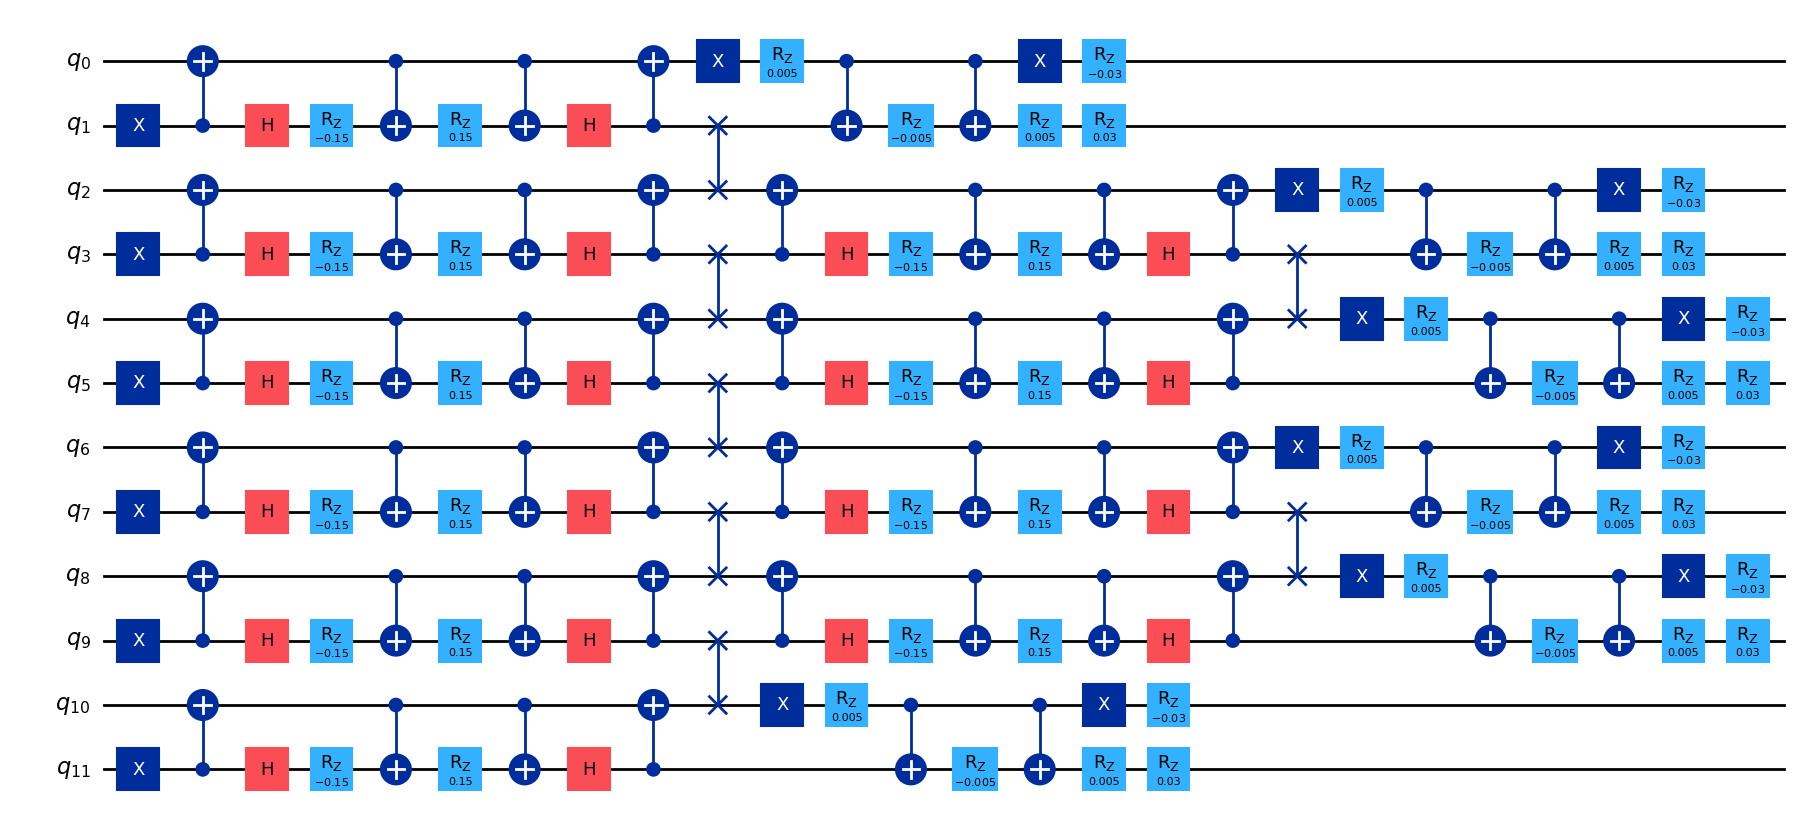

In [5]:
# Build circuits: meson initial state and vacuum (SCV) initial state
circuits_mid = [
    construct_circuit(num_lattice_point, d, c, theta, m,
                      barriers=False, measurement=False,
                      add_init_state=True, inverse_mid=True)
    for d in trotter_steps
]

circuits = [
    construct_circuit(num_lattice_point, d, c, theta, m,
                      barriers=False, measurement=False,
                      add_init_state=True, inverse_mid=False)
    for d in trotter_steps
]

# Visualize a single Trotter step
print(f"Circuit for 1 Trotter step: {circuits[0].num_qubits} qubits, depth {circuits[0].depth()}")
circuits[0].draw('mpl', fold=-1)

### Step 2: Optimize problem for quantum hardware execution

We define the observables: single-qubit $Z$ measurements on every qubit. From $\langle Z \rangle$ we extract occupation probabilities and then the staggered fermion number $n_f(r)$ at each lattice site $r$.

In [6]:
# Z observable on each qubit
observables = [
    SparsePauliOp('I' * i + 'Z' + 'I' * (num_qubits - i - 1))
    for i in range(num_qubits)
]

print(f"Number of observables: {len(observables)}")

Number of observables: 12


### Step 3: Execute using Qiskit primitives

We use `StatevectorEstimator` for exact noiseless simulation at small scale.

In [7]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

# Run meson circuits
pubs_mid = [(circuit, observables) for circuit in circuits_mid]
result_mid = estimator.run(pubs_mid).result()

# Run vacuum (SCV) circuits
pubs = [(circuit, observables) for circuit in circuits]
result = estimator.run(pubs).result()

# Extract expectation values
raw_expvals_mid = [result_mid[i].data.evs[::-1] for i in range(len(circuits_mid))]
raw_expvals = [result[i].data.evs[::-1] for i in range(len(circuits))]

print(f"Computed expectation values for {len(raw_expvals)} Trotter steps")

Computed expectation values for 20 Trotter steps


### Step 4: Post-process and return result in desired classical format

We convert expectation values to the staggered fermion number $n_f(r, t)$ and apply the differential measurement protocol (meson $-$ vacuum) to produce the hadron propagation heatmap. This reproduces the structure of Figure 3 from the reference paper: lattice site $r$ on the x-axis, Trotter step (time) $t$ on the y-axis, and $n_f(r,t)$ as the color scale.

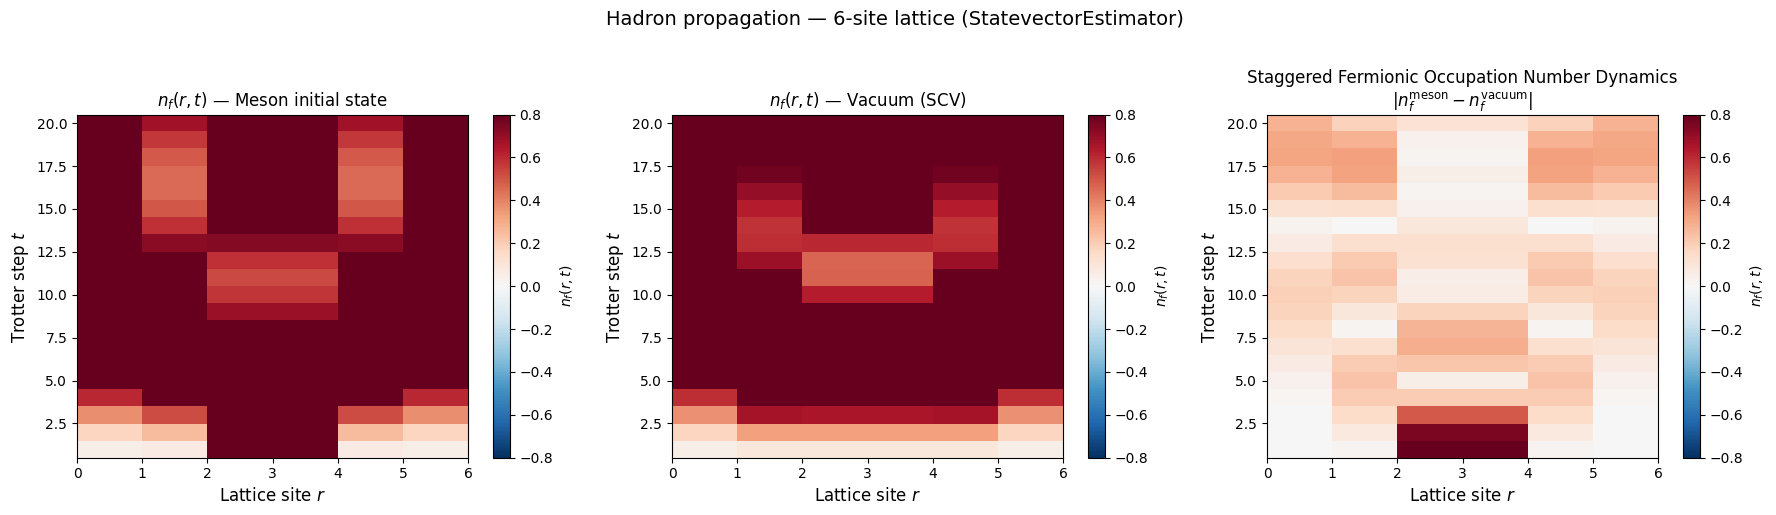

In [8]:
# Compute fermion numbers
N_mid_sim = get_number(raw_expvals_mid, num_lattice_point)
N_sim = get_number(raw_expvals, num_lattice_point)
N_diff_sim = calculate_difference(N_mid_sim, N_sim, num_lattice_point)

# --- Reproduce Figure 3 style: Staggered Fermionic Occupation Number Dynamics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convert to numpy arrays for plotting
N_mid_arr = np.array(N_mid_sim)
N_arr = np.array(N_sim)
N_diff_arr = np.array(N_diff_sim)

# Meson evolution
norm1 = TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)
im0 = axes[0].imshow(N_mid_arr, aspect='auto', origin='lower', cmap='RdBu_r',
                      norm=norm1,
                      extent=[0, num_lattice_point, 0.5, len(trotter_steps)+0.5])
axes[0].set_xlabel('Lattice site $r$', fontsize=12)
axes[0].set_ylabel('Trotter step $t$', fontsize=12)
axes[0].set_title('$n_f(r,t)$ — Meson initial state', fontsize=12)
plt.colorbar(im0, ax=axes[0], label='$n_f(r,t)$')

# Vacuum (SCV) evolution
im1 = axes[1].imshow(N_arr, aspect='auto', origin='lower', cmap='RdBu_r',
                      norm=norm1,
                      extent=[0, num_lattice_point, 0.5, len(trotter_steps)+0.5])
axes[1].set_xlabel('Lattice site $r$', fontsize=12)
axes[1].set_ylabel('Trotter step $t$', fontsize=12)
axes[1].set_title('$n_f(r,t)$ — Vacuum (SCV)', fontsize=12)
plt.colorbar(im1, ax=axes[1], label='$n_f(r,t)$')

# Differential: meson - vacuum
norm2 = TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)
im2 = axes[2].imshow(N_diff_arr, aspect='auto', origin='lower', cmap='RdBu_r',
                      norm=norm2,
                      extent=[0, num_lattice_point, 0.5, len(trotter_steps)+0.5])
axes[2].set_xlabel('Lattice site $r$', fontsize=12)
axes[2].set_ylabel('Trotter step $t$', fontsize=12)
axes[2].set_title('Staggered Fermionic Occupation Number Dynamics\n$|n_f^{\\mathrm{meson}} - n_f^{\\mathrm{vacuum}}|$', fontsize=12)
plt.colorbar(im2, ax=axes[2], label='$n_f(r,t)$')

plt.suptitle(f'Hadron propagation — {num_lattice_point}-site lattice (StatevectorEstimator)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Large-scale hardware example

We now scale up to a 30-site lattice (60 qubits) on IBM quantum hardware. At this scale, the circuit at 20 Trotter steps comprises over 17,000 two-qubit gates and 60,000+ single-qubit gates.

In [11]:
layout = [1,2,3,16,23,22,21,36,41,42,43,44,45,46,47,48,49,50,51,58,71,
70,69,68,67,66,65,77,85,86,87,88,89,90,91,92,93,94,95,99,115,114,113,112,111,110,
109,108,107,106,105,117,125,124,123,136,143,144,145,146]
len(layout)

60

In [12]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend, initial_layout=layout)
isa_circuits_mid = pm.run(circuits_mid_hw[0])

### Steps 1-4 compressed into single code block

Key aspects of the hardware workflow:

- 20 Trotter steps for the meson and vacuum circuits (interleaved for minimal drift)
- Transpilation with `optimization_level=1` — the circuit layout is already isomorphic to the device topology (a linear chain), so no routing SWAPs are needed. The transpiler is used solely to select a low-noise chain of physical qubits and decompose gates into the native gate set.
- `EstimatorV2` with TREX readout error mitigation and Pauli twirling
- `Batch` session to submit all jobs together

In [2]:
# -------------------------Step 1: Define parameters & build circuits-------------------------

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()

num_lattice_point_hw = 30
num_qubits_hw = 2 * num_lattice_point_hw  # 60 qubits
c_hw = 0.15
theta_hw = 0.01
m_hw = 0.03
trotter_steps_hw = range(1, 21)  # 20 Trotter steps

# Build meson and vacuum circuits
circuits_mid_hw = [
    construct_circuit(num_lattice_point_hw, d, c_hw, theta_hw, m_hw,
                      barriers=False, measurement=False,
                      add_init_state=True, inverse_mid=True)
    for d in trotter_steps_hw
]

circuits_hw = [
    construct_circuit(num_lattice_point_hw, d, c_hw, theta_hw, m_hw,
                      barriers=False, measurement=False,
                      add_init_state=True, inverse_mid=False)
    for d in trotter_steps_hw
]

print(f"Built {len(circuits_hw)} circuit pairs for {num_qubits_hw} qubits")

# -------------------------Step 2: Transpile for hardware-------------------------
# The circuit topology is a linear chain, isomorphic to the device topology.
# We use optimization_level=1 since no routing SWAPs are needed — the transpiler
# only needs to select a low-noise qubit chain and decompose to native gates.

backend = service.backend('ibm_boston')

layout = [
    140,141,142,143,
    136,
    123,122,121,
    116,
    101,102,103,
    96,
    83,82,81,
    76,
    61,62,63,64,65,66,67,68,69,
    78,
    89,88,87,
    97,
    107,106,105,
    117,
    125,126,127,
    137,
    147,148,149,150,151,152,153,154,155,
    139,
    135,134,133,132,131,130,129,
    118,
    109,110,111
]


pm = generate_preset_pass_manager(optimization_level=3, backend=backend, initial_layout=layout)

isa_circuits_mid = pm.run(circuits_mid_hw)
isa_circuits = pm.run(circuits_hw)

print(f"Transpiled circuits. Example depth: {isa_circuits[0].depth()}")

# Define and layout-map observables
observables_hw = [
    SparsePauliOp('I' * i + 'Z' + 'I' * (num_qubits_hw - i - 1))
    for i in range(num_qubits_hw)
]

isa_observables_mid = [
    [obs.apply_layout(isa_circuits_mid[i].layout) for obs in observables_hw]
    for i in range(len(isa_circuits_mid))
]
isa_observables = [
    [obs.apply_layout(isa_circuits[i].layout) for obs in observables_hw]
    for i in range(len(isa_circuits))
]

# Build PUBs — interleave meson and vacuum for each Trotter step
isa_pubs_mid = [
    (circ, obs) for circ, obs in zip(isa_circuits_mid, isa_observables_mid)
]
isa_pubs = [
    (circ, obs) for circ, obs in zip(isa_circuits, isa_observables)
]

pubs_to_execute = [
    [isa_pubs_mid[i], isa_pubs[i]]
    for i in range(len(isa_pubs))
]

# -------------------------Step 3: Execute on hardware-------------------------

from qiskit_ibm_runtime import EstimatorV2, Batch
from qiskit_ibm_runtime.options import (
    EstimatorOptions,
    ResilienceOptionsV2,
    TwirlingOptions,
    DynamicalDecouplingOptions,
)

twirling_options = TwirlingOptions(
    enable_gates=True,
    enable_measure=True,
    shots_per_randomization="auto",
    strategy="active-circuit",
)

resilience_options = ResilienceOptionsV2(
    measure_mitigation=True,   # TREX readout error mitigation
    zne_mitigation=False,      # ZNE turned off
)

dd_options = DynamicalDecouplingOptions(
    enable=False  # Circuit is sufficiently dense
)

options = EstimatorOptions(
    resilience=resilience_options,
    twirling=twirling_options,
    dynamical_decoupling=dd_options,
    default_shots=10_000,
)

ids = []
with Batch(backend=backend) as batch:
    for idx, pub in enumerate(pubs_to_execute):
        print(f'Submitting job for Trotter step {idx + 1}')
        estimator = EstimatorV2(mode=batch, options=options)
        estimator.skip_transpilation = True
        job = estimator.run(pub)
        ids.append(job.job_id())
    batch_id = batch.session_id

job_info = {'ids': ids, 'batch_id': batch_id}
print(f"Submitted {len(ids)} jobs. Batch ID: {batch_id}")

In [1]:
print(ids)

In [19]:
# -------------------------Step 4: Post-process results-------------------------

jobs = [service.job(job_id) for job_id in ids]
results = [job.result() for job in jobs]

# Extract expectation values (index 0 = meson, index 1 = vacuum)
raw_expvals_mid_hw = [result[0].data.evs[::-1] for result in results]
raw_expvals_hw = [result[1].data.evs[::-1] for result in results]

# Compute fermion numbers and differential
N_mid_hw = get_number(raw_expvals_mid_hw, num_lattice_point_hw)
N_hw = get_number(raw_expvals_hw, num_lattice_point_hw)
N_diff_hw = calculate_difference(N_mid_hw, N_hw, num_lattice_point_hw)

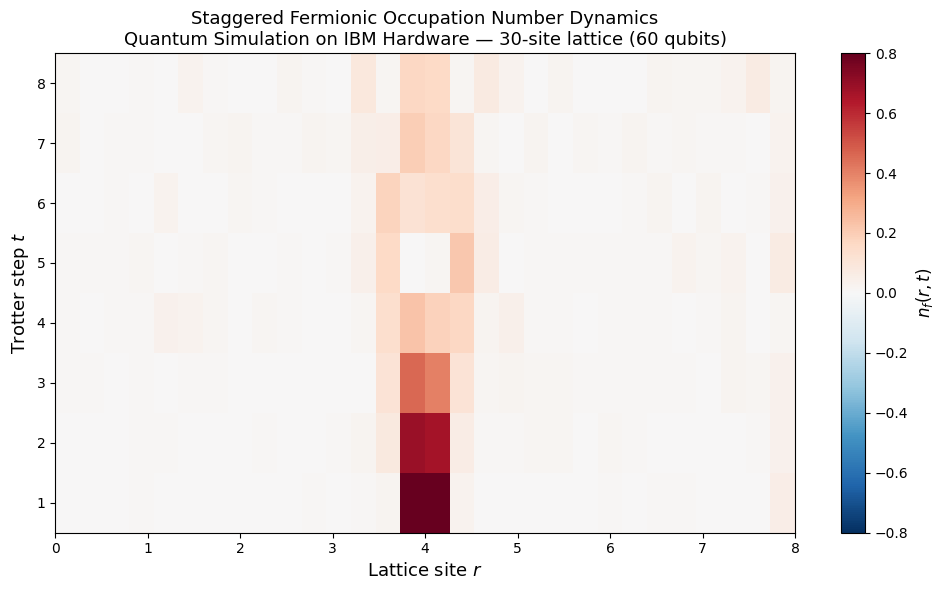

In [24]:
N_diff_hw_arr = np.array(N_diff_hw)

fig, ax = plt.subplots(figsize=(10, 6))
norm = TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)
im = ax.imshow(N_diff_hw_arr[:8], aspect='auto', origin='lower', cmap='RdBu_r',
               norm=norm,
               extent=[0, 8, 0.5, len(trotter_steps_hw[:8])+0.5])
ax.set_xlabel('Lattice site $r$', fontsize=13)
ax.set_ylabel('Trotter step $t$', fontsize=13)
ax.set_title('Staggered Fermionic Occupation Number Dynamics\nQuantum Simulation on IBM Hardware — 30-site lattice (60 qubits)',
             fontsize=13)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('$n_f(r,t)$', fontsize=12)
plt.tight_layout()
plt.show()

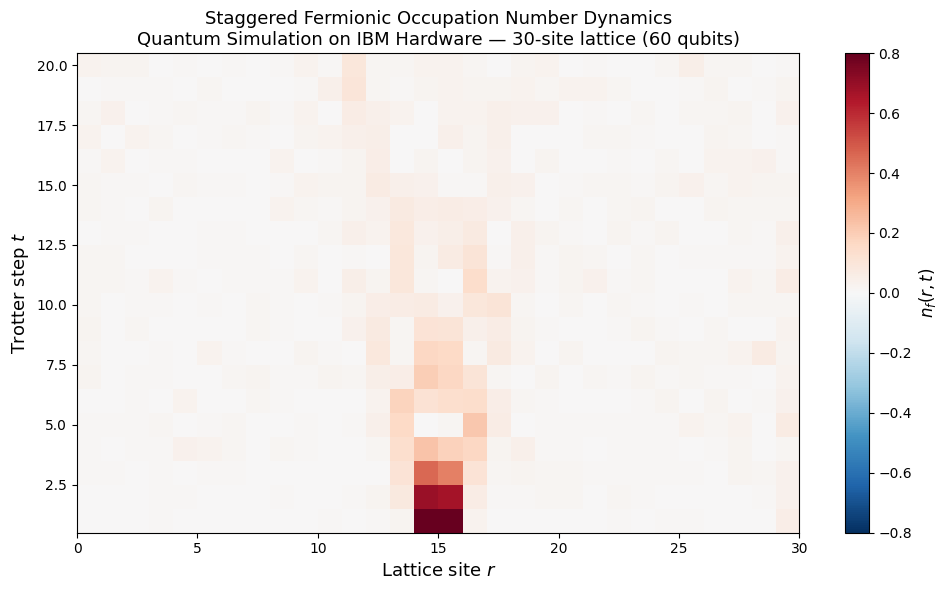

In [ ]:
# --- Staggered Fermionic Occupation Number Dynamics (Fig. 3 style) ---
N_diff_hw_arr = np.array(N_diff_hw)

fig, ax = plt.subplots(figsize=(10, 6))
norm = TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)
im = ax.imshow(N_diff_hw_arr[:10], aspect='auto', origin='lower', cmap='RdBu_r',
               norm=norm,
               extent=[0, num_lattice_point_hw, 0.5, len(trotter_steps_hw)+0.5])
ax.set_xlabel('Lattice site $r$', fontsize=13)
ax.set_ylabel('Trotter step $t$', fontsize=13)
ax.set_title('Staggered Fermionic Occupation Number Dynamics\nQuantum Simulation on IBM Hardware — 30-site lattice (60 qubits)',
             fontsize=13)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('$n_f(r,t)$', fontsize=12)
plt.tight_layout()
plt.show()

## Classical benchmarking via Pauli Propagation

The Pauli Propagation Method (PPM) provides a noiseless classical simulation of the quantum circuit by back-propagating measured observables through the circuit in the Heisenberg picture. Under Clifford layers (CNOT, H, S, X gates), Pauli operators map to other Pauli operators without increasing the number of terms. Non-Clifford layers (the $R_z$ gates in our circuit) can cause branching — in the worst case doubling the number of terms — but many branches have small coefficients and can be truncated.

The workflow with [`pauli-prop`](https://github.com/Qiskit/pauli-prop) is:
1. **Split** the circuit into its Clifford and non-Clifford parts using `evolve_through_cliffords`
2. **Propagate** each observable through the non-Clifford part using `propagate_through_circuit`, keeping up to `max_terms` Pauli terms and dropping terms with coefficients below the truncation threshold `atol`
3. **Evolve** the result through the Clifford part using Qiskit's built-in Clifford support
4. **Extract** the expectation value by summing coefficients of diagonal Pauli terms (containing only $I$ and $Z$)

### Truncation threshold

The `atol` parameter in `propagate_through_circuit` controls how aggressively small Pauli branches are pruned. A very tight threshold (e.g., `1e-12`) retains nearly all branches and gives exact results, but simulation time grows steeply with circuit depth — the 120-qubit simulation above took ~8.5 hours with the default settings. Raising the threshold (e.g., to `1e-6` or `1e-3`) discards terms whose coefficients fall below that value, dramatically reducing the number of tracked terms and speeding up computation. The trade-off is a small, controllable approximation error that can be validated by comparing results at different thresholds.

In [11]:
import time
from pauli_prop import evolve_through_cliffords, propagate_through_circuit

# ── PPM Configuration ──
# Truncation threshold: controls the speed/accuracy trade-off.
PPM_THRESHOLD = 1e-3

# Maximum Pauli terms to track per observable (hard cap on memory/time)
PPM_MAX_TERMS = 66_000

print(f"PPM settings: atol={PPM_THRESHOLD}, max_terms={PPM_MAX_TERMS}")

# We propagate each single-qubit Z observable through each circuit.
# For PPM, we work with the un-transpiled circuits (ideal noiseless simulation).

observables_pp = [
    SparsePauliOp('I' * i + 'Z' + 'I' * (num_qubits_hw - i - 1))
    for i in range(num_qubits_hw)
]

def ppm_expectation_values(circuit, observables, max_terms=PPM_MAX_TERMS, atol=PPM_THRESHOLD):
    """Compute expectation values of single-qubit Z observables via Pauli propagation.
    
    Args:
        circuit: The quantum circuit to simulate.
        observables: List of single-qubit Z observables.
        max_terms: Maximum number of Pauli terms to retain (hard cap).
        atol: Absolute tolerance — Pauli terms with coefficients below this
              value are discarded during propagation. Larger values give
              faster simulation at the cost of approximation accuracy.
    """
    circuit = circuit.decompose(['swap'])  # decompose SWAPs into 3 CX gates
    cliff, non_cliff = evolve_through_cliffords(circuit)
    
    evs = []
    for obs in observables:
        evolved_obs = propagate_through_circuit(
            obs, non_cliff, max_terms=max_terms, atol=atol, frame="h"
        )[0]
        evolved_obs.paulis = evolved_obs.paulis.evolve(cliff, frame="h")
        diagonal_mask = ~evolved_obs.paulis.x.any(axis=1)
        ev = float(evolved_obs.coeffs[diagonal_mask].sum().real)
        evs.append(ev)
    return np.array(evs)


# Run PPM for each Trotter step and record wall-clock time
pp_expvals_mid = []
pp_expvals = []
pp_times = []

for idx, d in enumerate(trotter_steps_hw):
    t_start = time.perf_counter()
    
    # Meson circuit
    evs_mid = ppm_expectation_values(circuits_mid_hw[idx], observables_pp)
    
    # Vacuum circuit
    evs_vac = ppm_expectation_values(circuits_hw[idx], observables_pp)
    
    elapsed = time.perf_counter() - t_start
    pp_times.append(elapsed)
    
    pp_expvals_mid.append(evs_mid[::-1])
    pp_expvals.append(evs_vac[::-1])
    
    print(f"Trotter step {d:2d}: {elapsed:.1f} s")

print(f"\nTotal PPM simulation time: {sum(pp_times):.1f} s")
print(f"Truncation threshold used: {PPM_THRESHOLD}")

PPM settings: atol=0.001, max_terms=66000
Trotter step  1: 7.4 s
Trotter step  2: 12.5 s
Trotter step  3: 17.4 s
Trotter step  4: 22.5 s
Trotter step  5: 27.1 s
Trotter step  6: 40.4 s
Trotter step  7: 49.7 s
Trotter step  8: 54.9 s
Trotter step  9: 62.9 s
Trotter step 10: 71.9 s
Trotter step 11: 78.4 s
Trotter step 12: 84.4 s
Trotter step 13: 74.3 s
Trotter step 14: 78.0 s
Trotter step 15: 82.6 s
Trotter step 16: 88.2 s
Trotter step 17: 94.1 s
Trotter step 18: 100.7 s
Trotter step 19: 105.5 s
Trotter step 20: 119.6 s

Total PPM simulation time: 1272.4 s
Truncation threshold used: 0.001


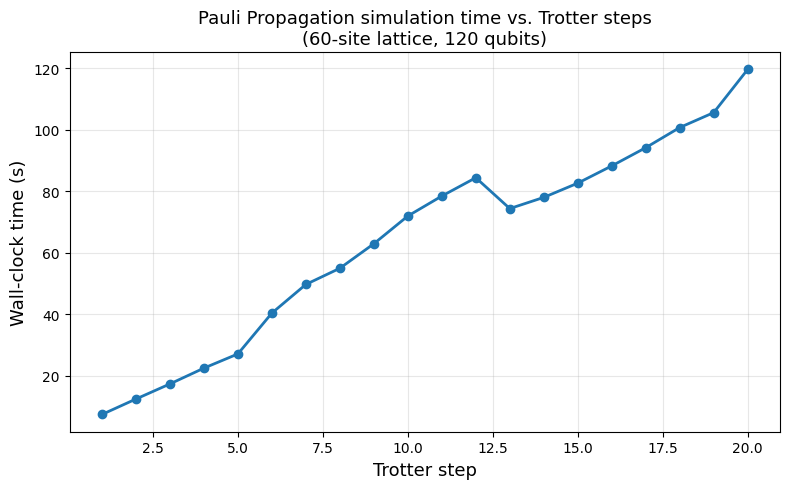

In [12]:
# --- PPM simulation time vs. Trotter steps ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(trotter_steps_hw), pp_times, 'o-', color='tab:blue', linewidth=2, markersize=6)
ax.set_xlabel('Trotter step', fontsize=13)
ax.set_ylabel('Wall-clock time (s)', fontsize=13)
ax.set_title('Pauli Propagation simulation time vs. Trotter steps\n(60-site lattice, 120 qubits)',
             fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

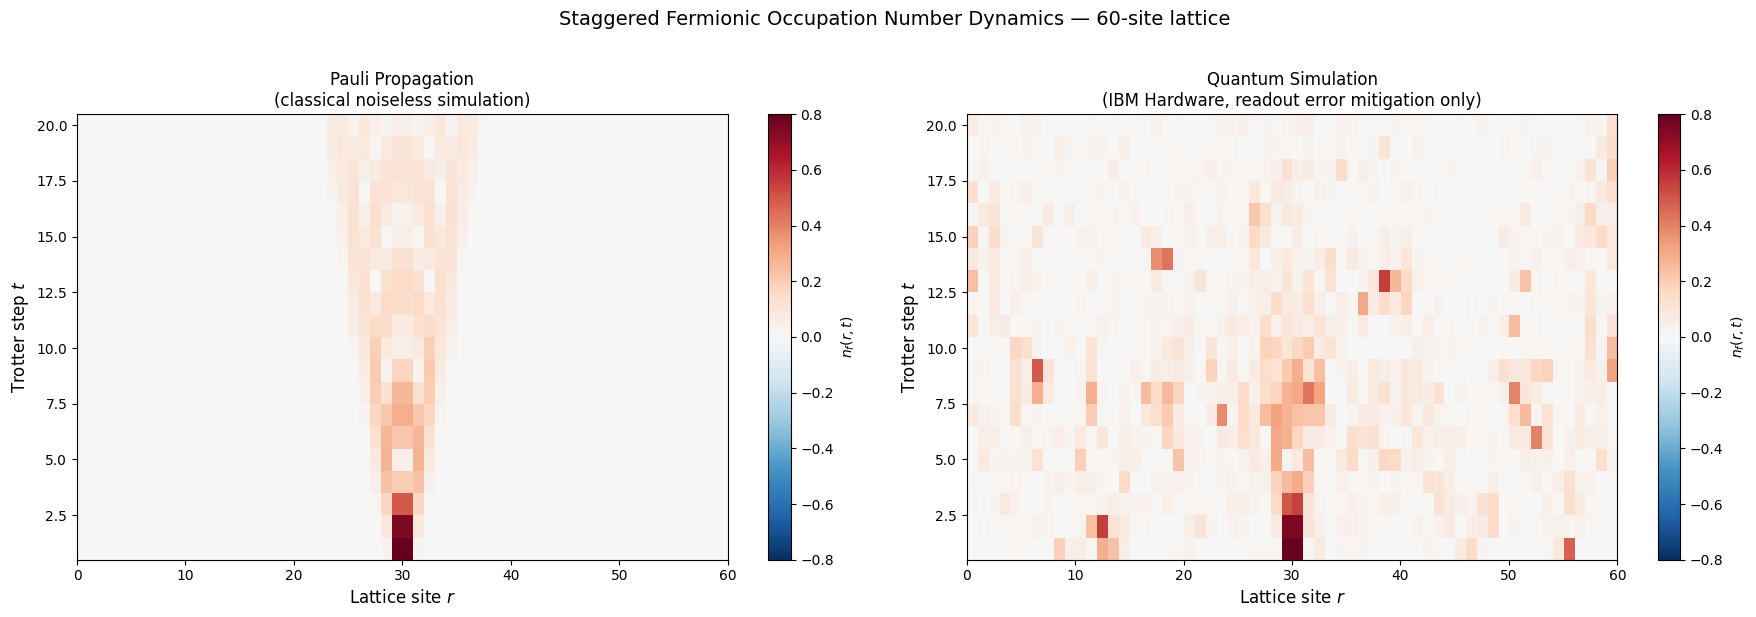

In [16]:
# --- PPM heatmap and comparison with hardware ---
N_mid_pp = get_number(pp_expvals_mid, num_lattice_point_hw)
N_pp = get_number(pp_expvals, num_lattice_point_hw)
N_diff_pp = calculate_difference(N_mid_pp, N_pp, num_lattice_point_hw)

N_diff_pp_arr = np.array(N_diff_pp)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
norm = TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)

# PPM result
im0 = axes[0].imshow(N_diff_pp_arr, aspect='auto', origin='lower', cmap='RdBu_r',
                      norm=norm,
                      extent=[0, num_lattice_point_hw, 0.5, len(trotter_steps_hw)+0.5])
axes[0].set_xlabel('Lattice site $r$', fontsize=12)
axes[0].set_ylabel('Trotter step $t$', fontsize=12)
axes[0].set_title('Pauli Propagation\n(classical noiseless simulation)', fontsize=12)
plt.colorbar(im0, ax=axes[0], label='$n_f(r,t)$')

# Hardware result
im1 = axes[1].imshow(N_diff_hw_arr, aspect='auto', origin='lower', cmap='RdBu_r',
                      norm=norm,
                      extent=[0, num_lattice_point_hw, 0.5, len(trotter_steps_hw)+0.5])
axes[1].set_xlabel('Lattice site $r$', fontsize=12)
axes[1].set_ylabel('Trotter step $t$', fontsize=12)
axes[1].set_title('Quantum Simulation\n(IBM Hardware, readout error mitigation only)', fontsize=12)
plt.colorbar(im1, ax=axes[1], label='$n_f(r,t)$')

plt.suptitle('Staggered Fermionic Occupation Number Dynamics — 60-site lattice',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Next steps
If you found this work interesting, you might be interested in the following material:

<Admonition type="tip" title="Recommendations">

- [Explore Hamiltonian simulation tutorial](https://learning.quantum.ibm.com/tutorial/explore-hamiltonian-simulation) — for more on Trotterization and time evolution
- [Qiskit Estimator primitive documentation](https://quantum.cloud.ibm.com/docs/en/guides/estimator) — for details on configuring error mitigation options
- [Error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques) — to learn about TREX, ZNE, and other mitigation methods
- [Qiskit Pauli Propagation (pauli-prop)](https://github.com/Qiskit/pauli-prop) — Rust-accelerated classical simulation via Pauli back-propagation

### References
[1] The original paper: Ilčić, Majumdar, Mathew et al. "Observation of Robust and Coherent Non-Abelian Hadron Dynamics on Noisy Quantum Processors" (2026)

</Admonition>